## Imports

In [1]:
from environment import Environment
from agent import Agent

2025-06-26 02:57:07.512213: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-26 02:57:07.521249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750886827.532155 2531082 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750886827.535426 2531082 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750886827.549417 2531082 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
from tensorflow.keras.regularizers import l2

## Environment (Low Risk Aversion)

### Initialization

In [3]:
env_low_risk=Environment(
    number_shares=1,
    trading_time=10,
    trading_steps=10,
    stock_volatility=0.15,
    permanent_impact_factor=0.1,
    temporary_impact_factor=0.1,
    risk_aversion_factor=0.0001
)

### Environment State

In [4]:
state=env_low_risk.get_state()

#### State1: (Time Series Data of number of shares traded) for LSTM Model

In [5]:
state[0]

[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]]

#### State2: (Remaining Share, Curr. Trading Step, Permanent Impact, Temporary Impact, Execution Risk) for Dense Model

In [6]:
state[1]

[1.0, 0.0, 0.0, 0.0, 0.0]

### Plot - Optimal Execution Strategy (Low Risk)

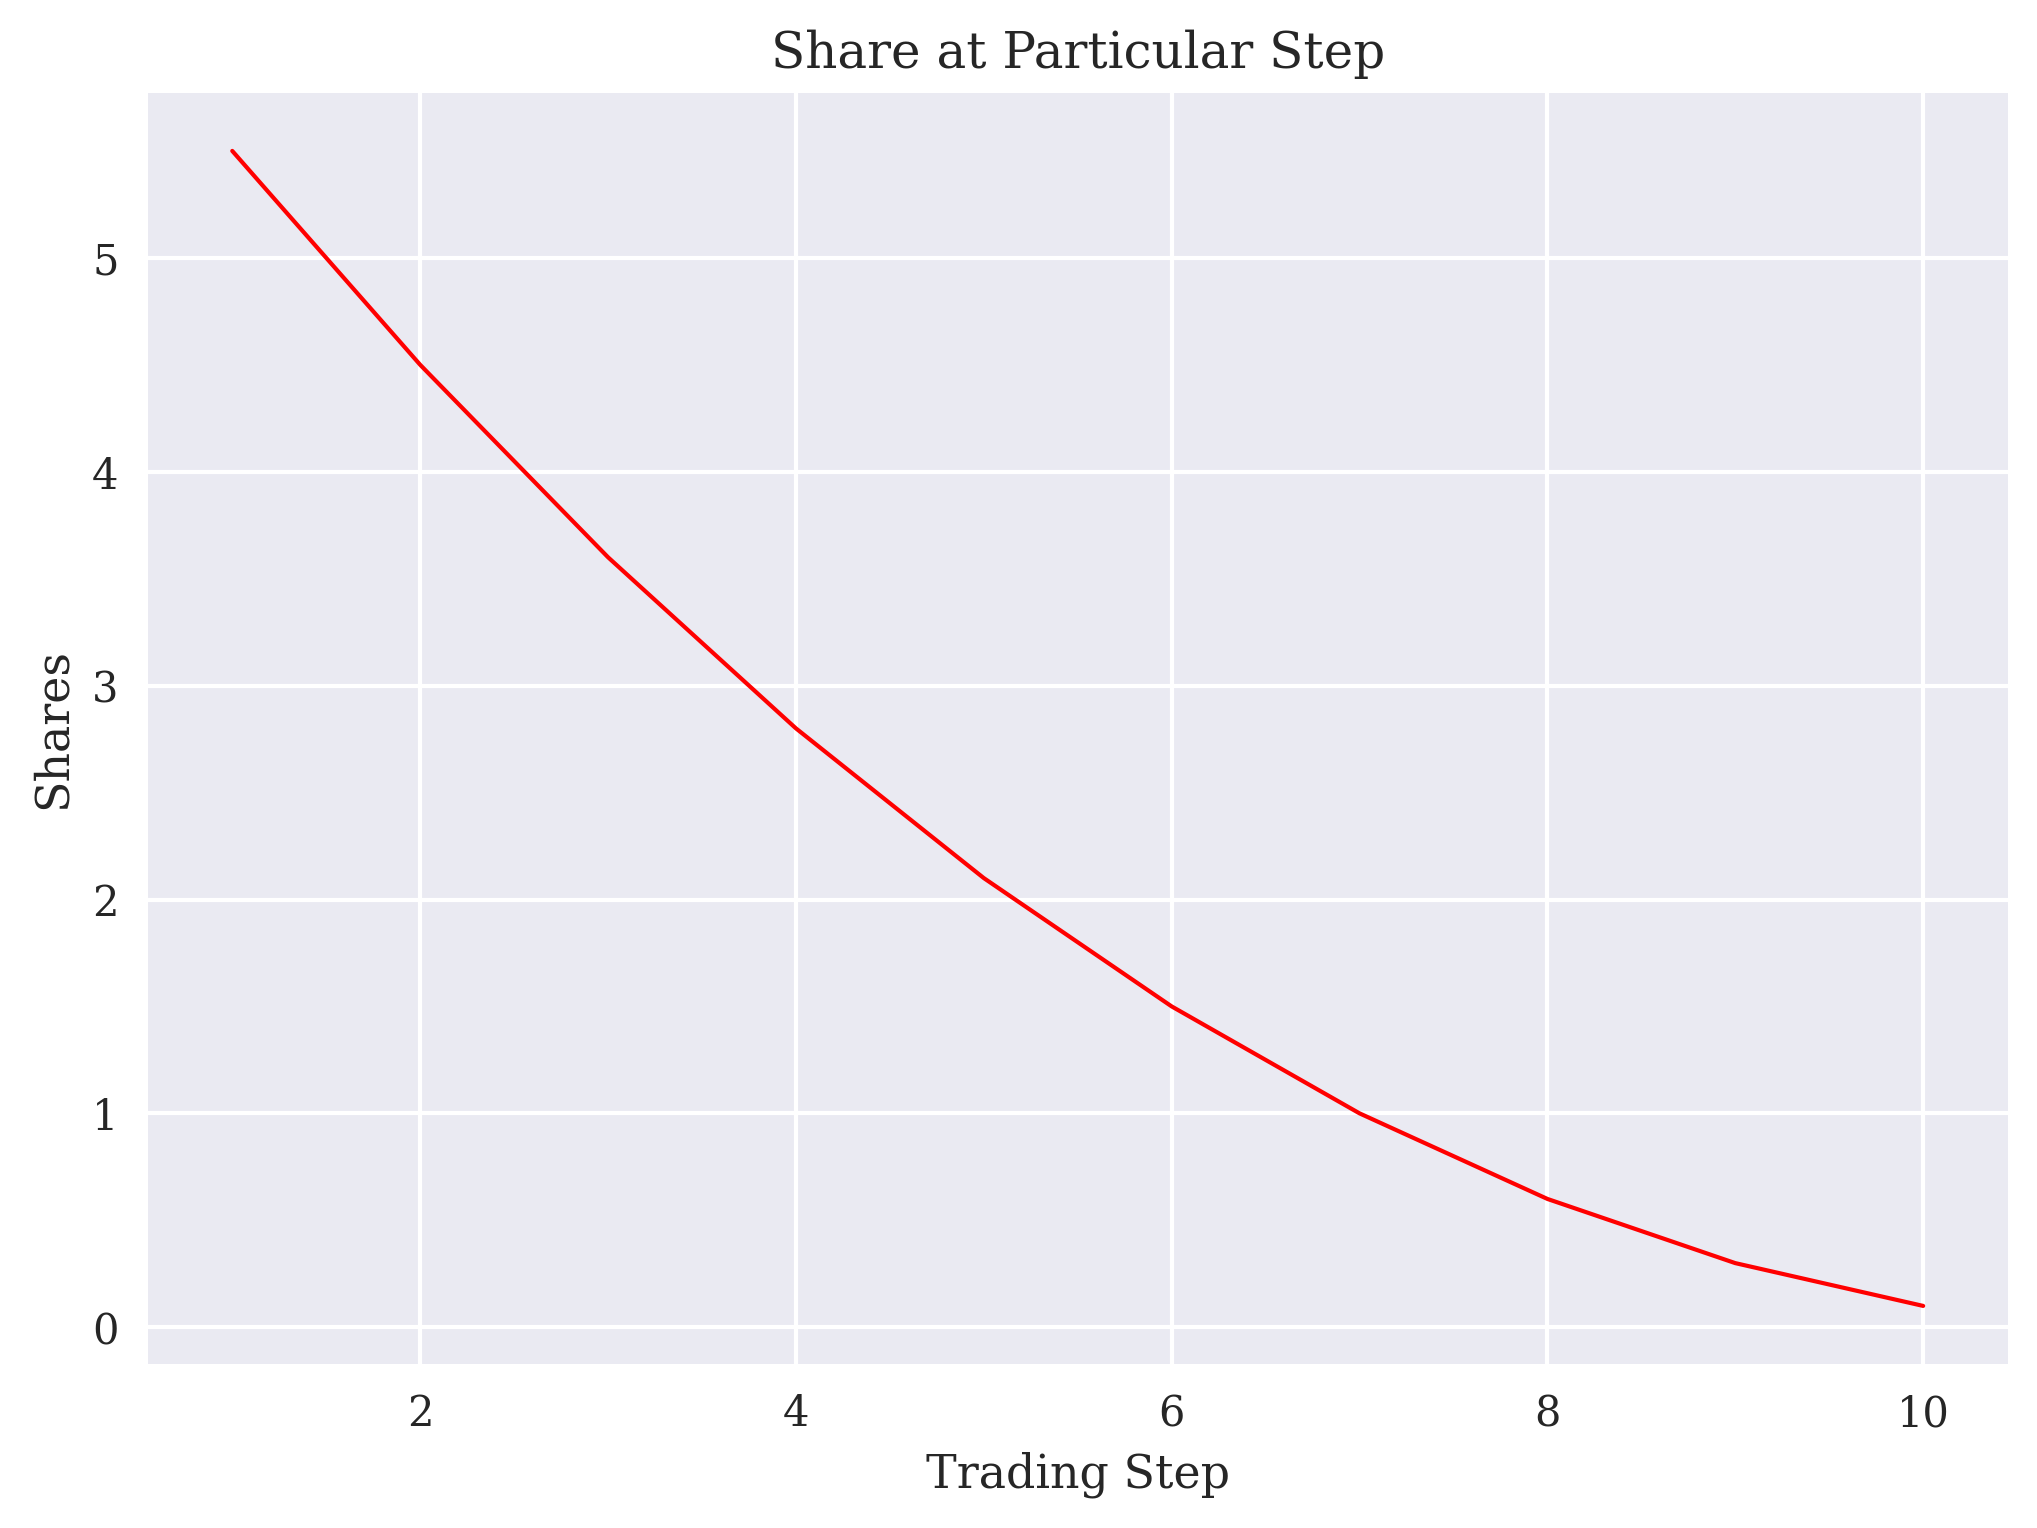

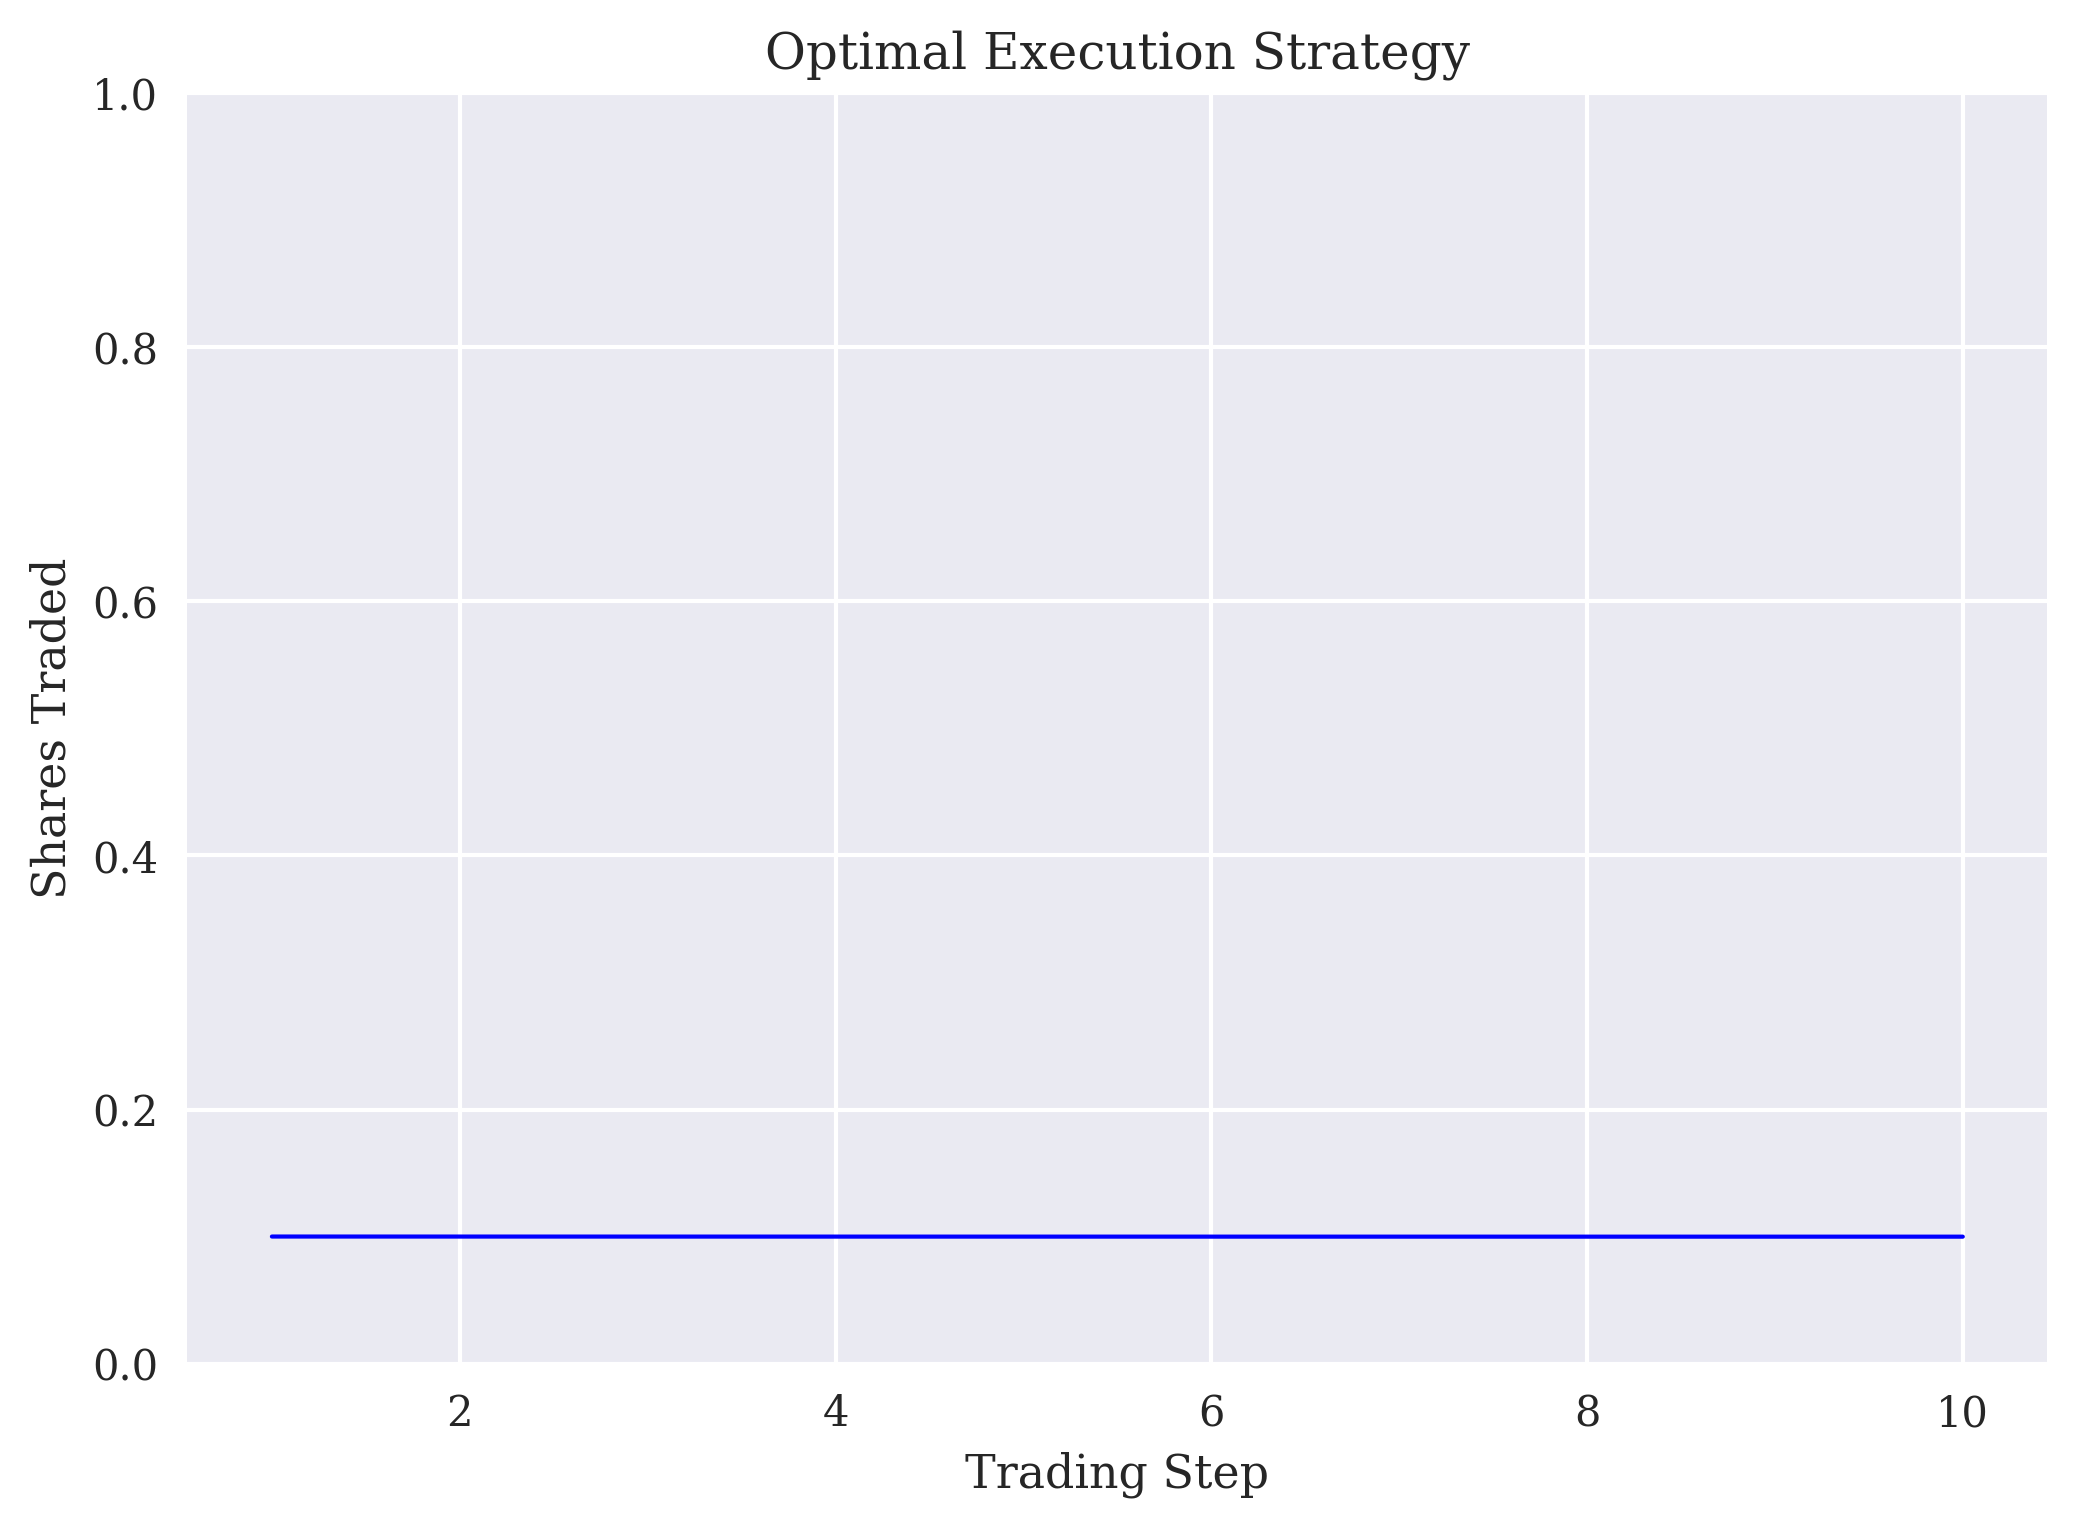

In [7]:
env_low_risk.plot()

## Environment (High Risk Aversion)

### Initialization

In [8]:
env_high_risk=Environment(
    number_shares=1,
    trading_time=10,
    trading_steps=10,
    stock_volatility=0.15,
    permanent_impact_factor=0.1,
    temporary_impact_factor=0.1,
    risk_aversion_factor=0.2
)

### Plot - Optimal Execution Strategy (High Risk)

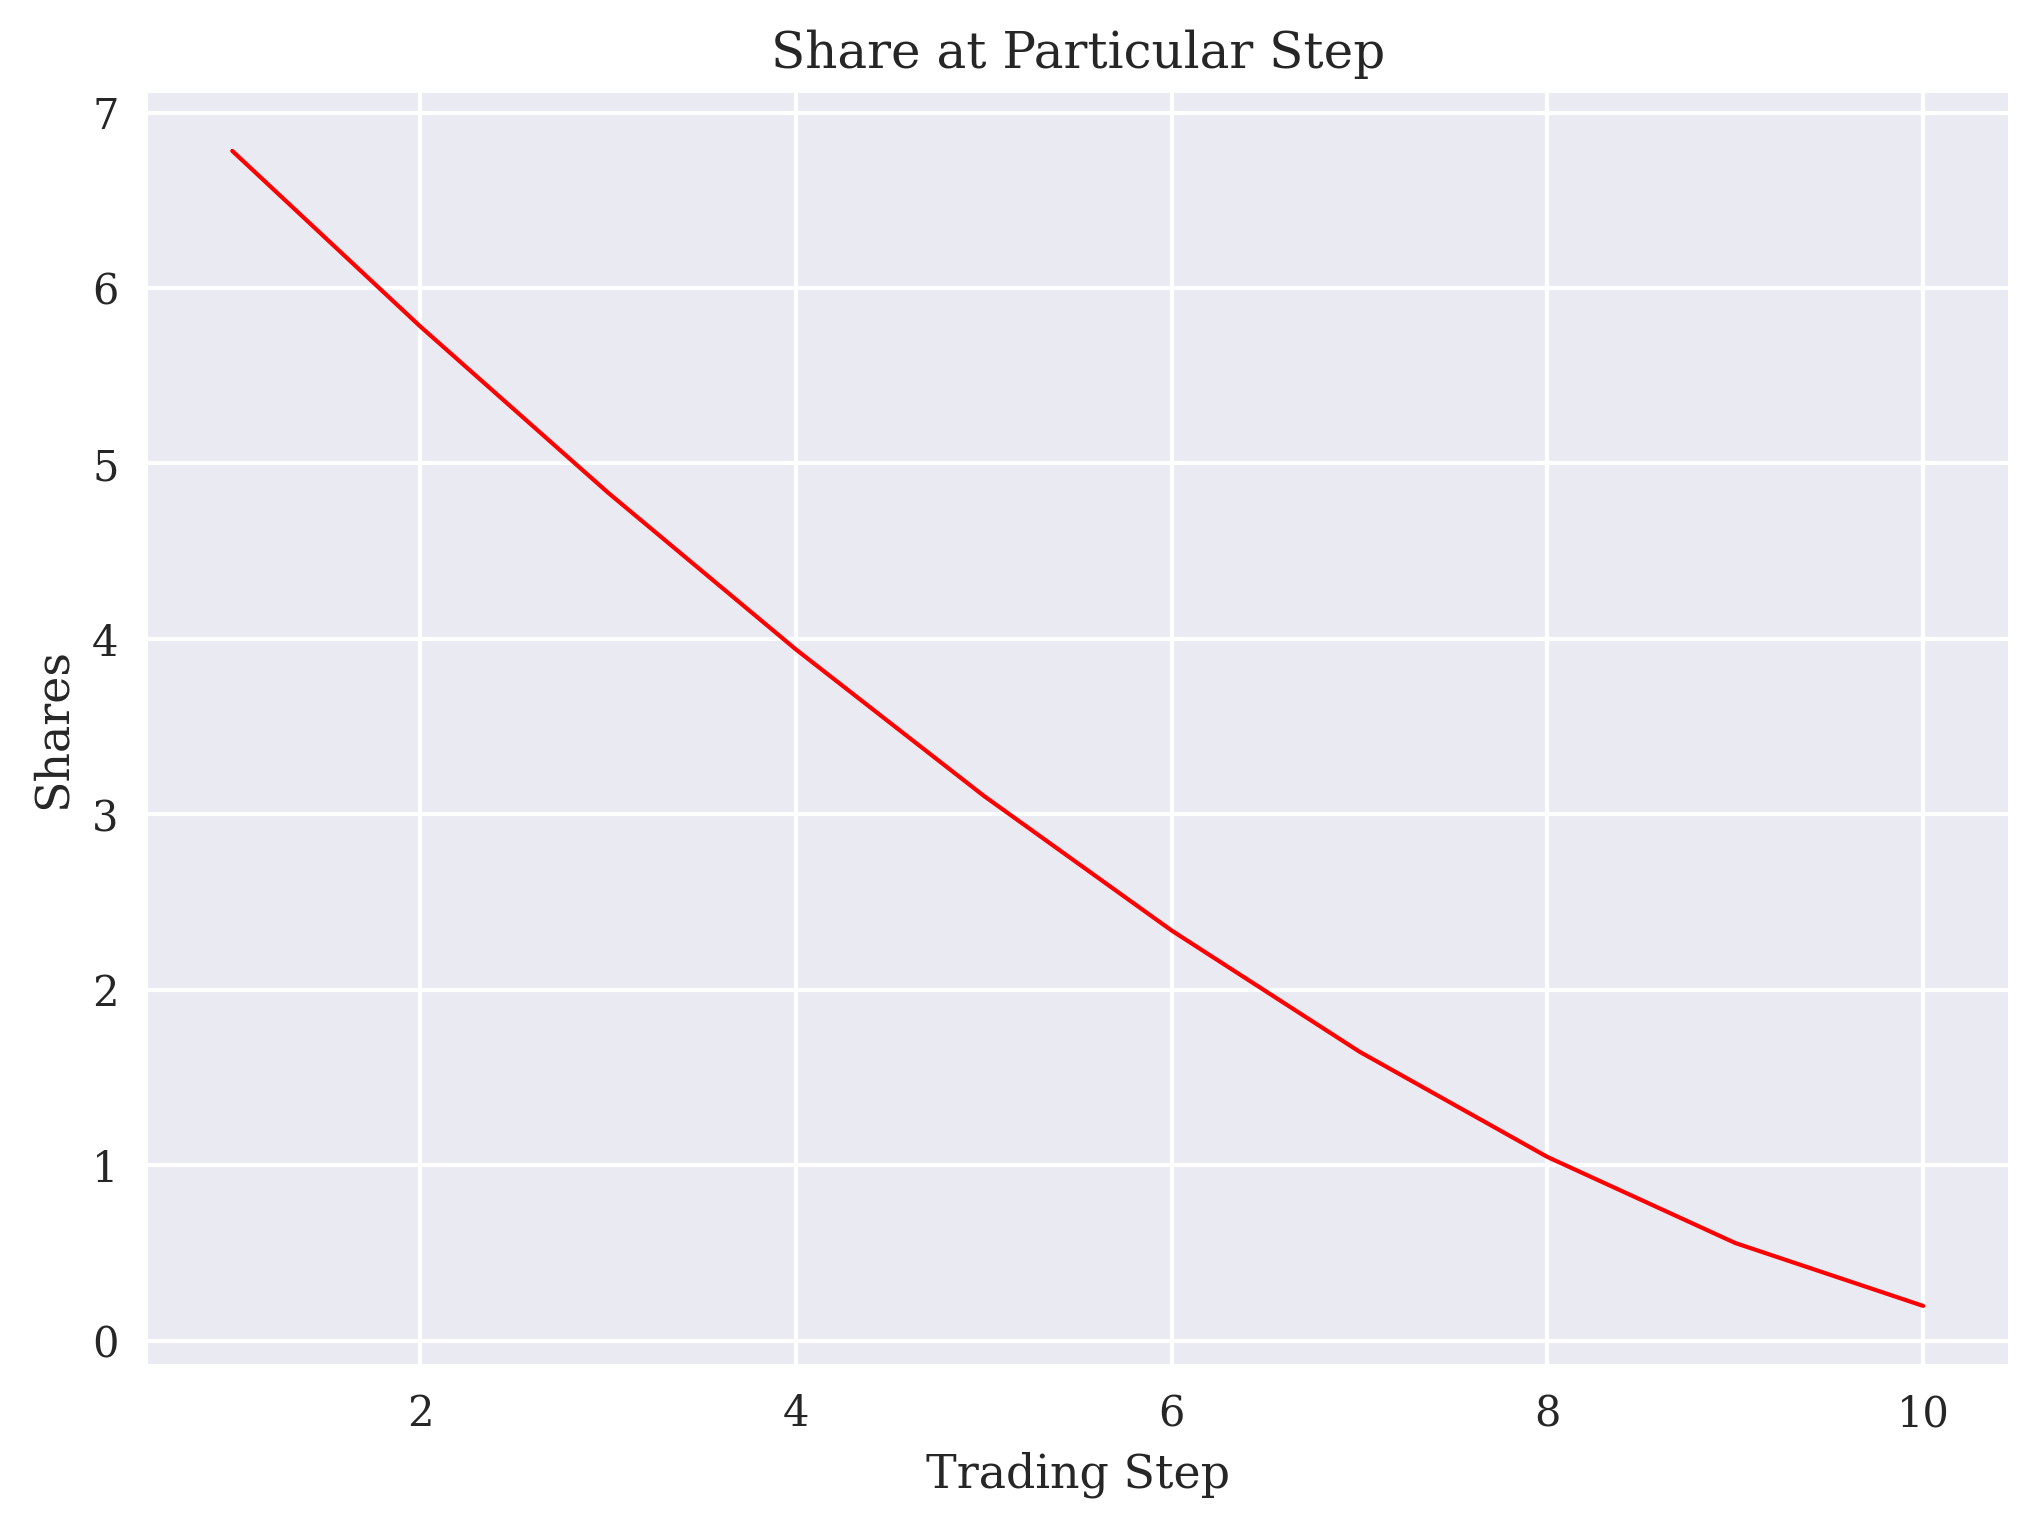

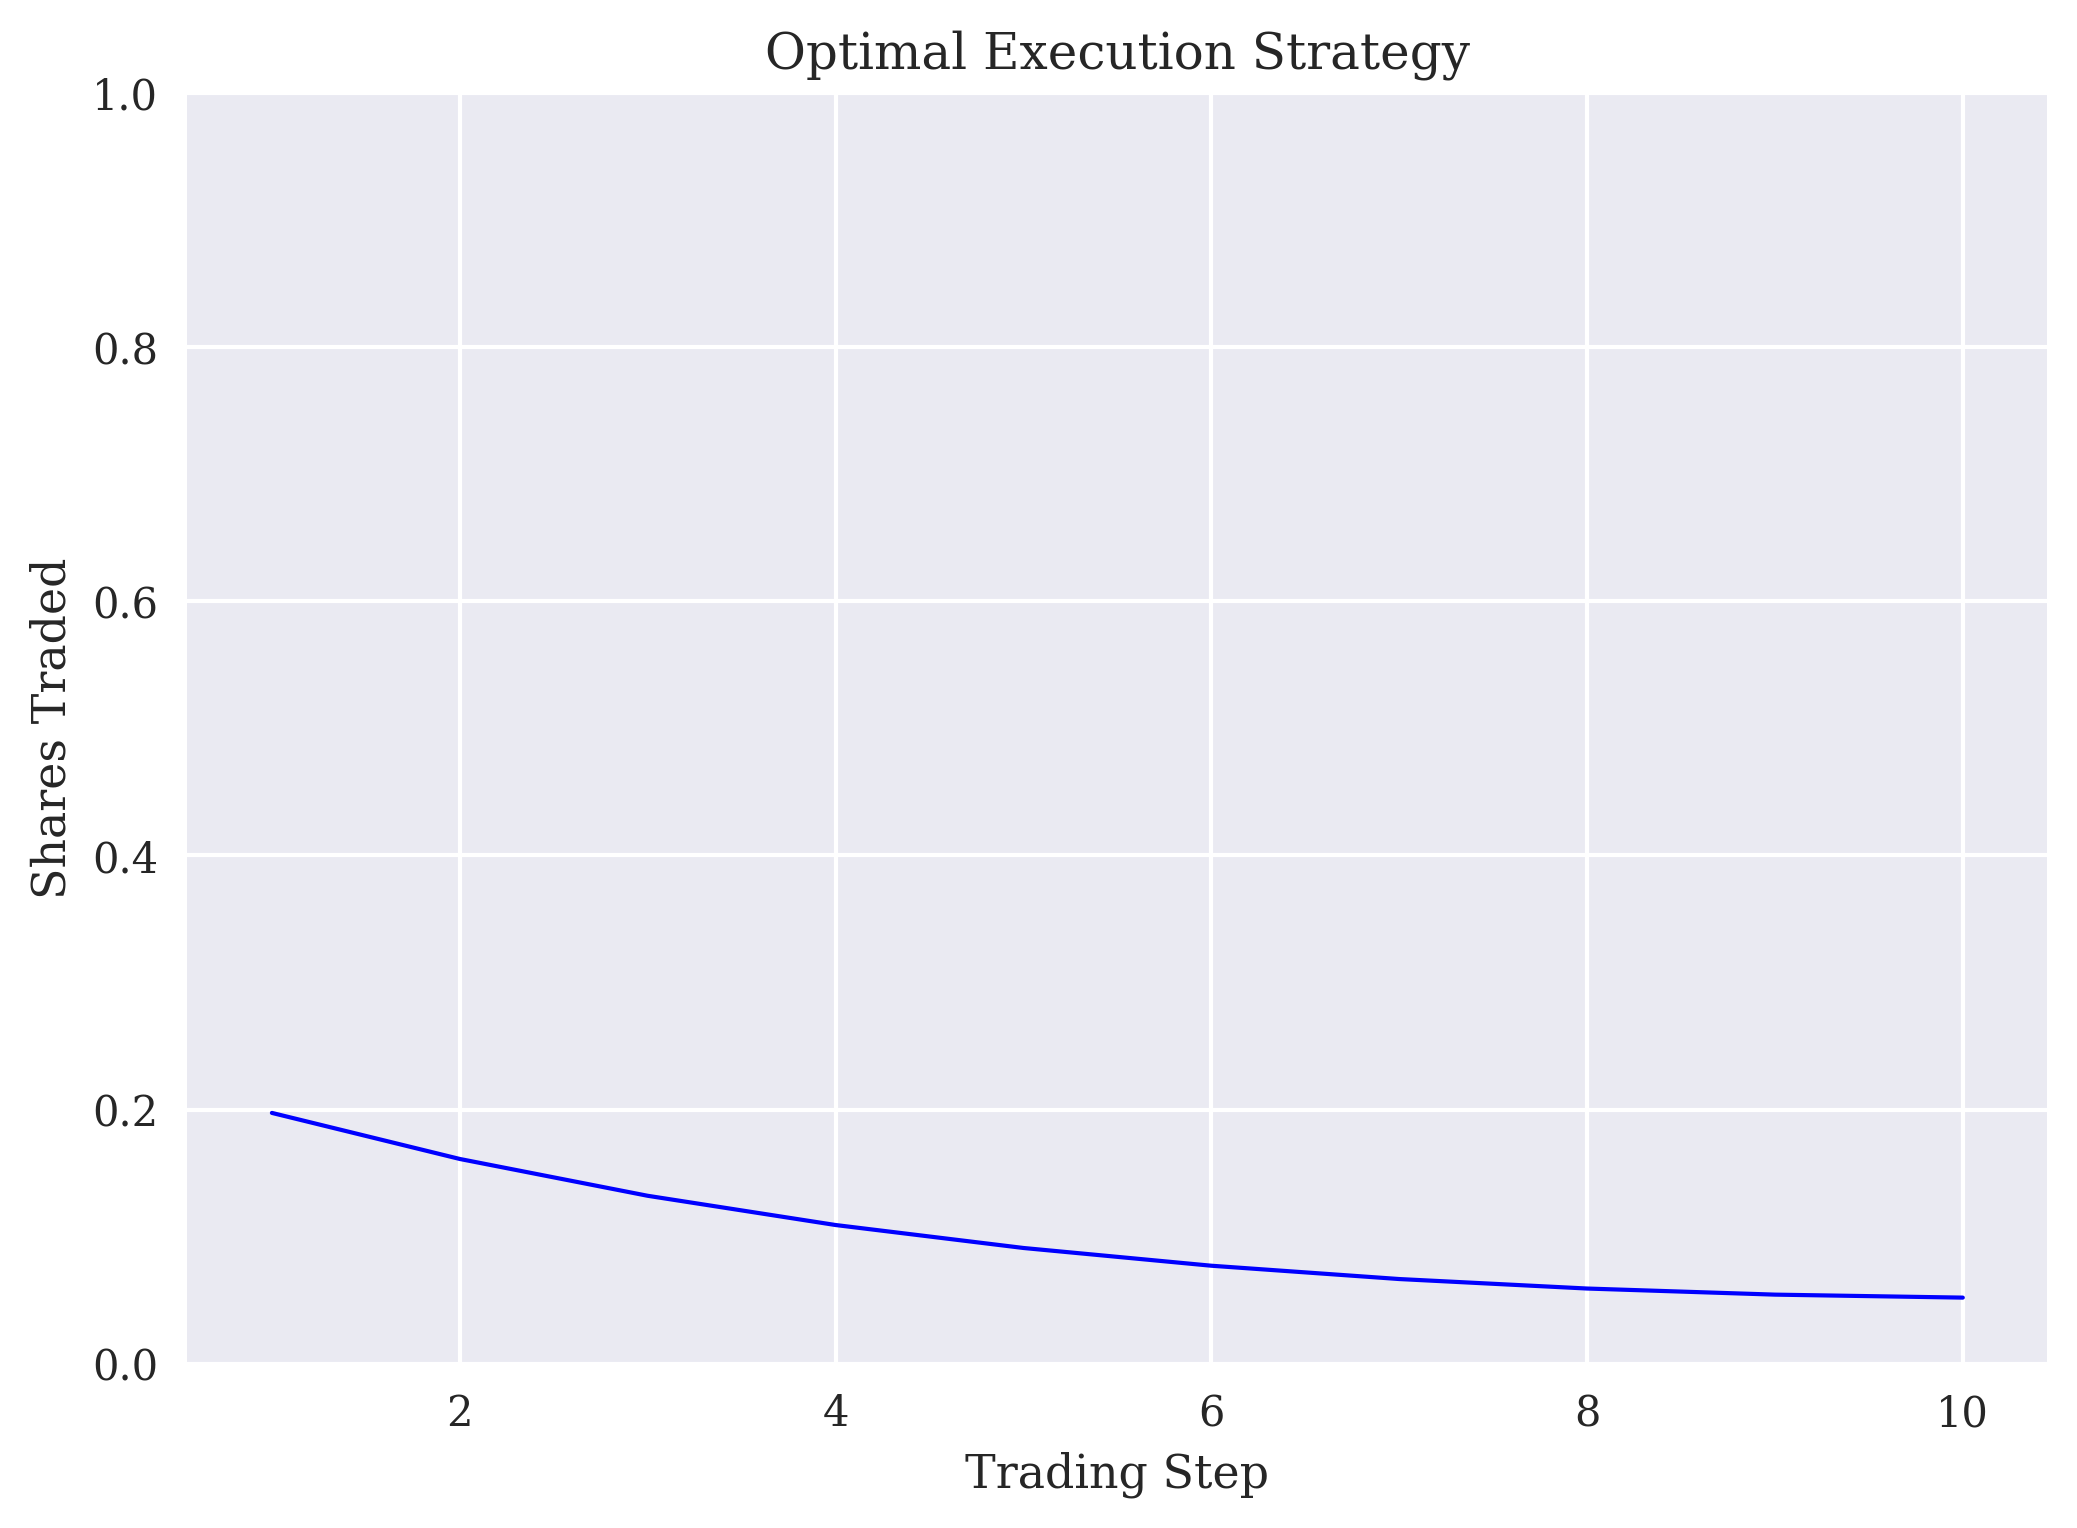

In [9]:
env_high_risk.plot()

## Agent

### Model Config

#### Actor Model Config

In [10]:
actor_model_config={
    "Model_1":[
        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":False
        }
    ],
    

    "Model_2":[
        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
         {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ],

    "Final_Model":[
        {
            "units":128,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":256,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":1,
            "activation":"sigmoid",
            "kernel_initializer":"glorot_uniform",
            "kernel_regularizer":None
        }
        
    ]
    
}

In [11]:
critic_model_config={
    "Model_1":[
        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":True
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None,
            "return_sequences":False
        }
    ],
    

    "Model_2":[
        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
         {
            "units":32,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ],

    "Final_Model":[
        {
            "units":128,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":256,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },
        {
            "units":64,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":16,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":l2(0.007)
        },

        {
            "units":8,
            "activation":"relu",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        },

        {
            "units":1,
            "activation":"linear",
            "kernel_initializer":"he_uniform",
            "kernel_regularizer":None
        }
        
    ]
    
}

### Optimizer Config

#### Actor Optimizer Config

In [12]:
actor_optimizer_config={
    "learning_rate":0.0005,
    "beta_1":0.96,
    "beta_2":0.99
}


#### Critic Optimizer Config

In [13]:
critic_optimizer_config={
    "learning_rate":0.001,
    "beta_1":0.97,
    "beta_2":0.98
}

### Initialization (High Risk Agent)

In [14]:
agent_high_risk=Agent(
    env=env_high_risk,
    actor_model_config=actor_model_config,
    critic_model_config=critic_model_config,
    actor_optimizer_config=actor_optimizer_config,
    critic_optimizer_config=critic_optimizer_config,
    actor_model_loss="binary_crossentropy",
    critic_model_loss="mse",
    gamma=0.7,
    exploration_episodes=250,
    batch_size=128,
    buffer_size=3000,
    epsilon=1.0,
    epsilon_min=0.1,
    epsilon_decay=0.9975
)

2025-06-26 02:57:09.478919: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### Models

#### Actor Model

In [15]:
agent_high_risk.get_model_architecture(agent_high_risk.actor_model)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 11, 16)    │      1,152 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │         48 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        144 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     24,832 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        544 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm_2[0][0],     │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     12,416 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │      1,040 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │          9 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,065 (375.25 KB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Critic Model

In [16]:
agent_high_risk.get_model_architecture(agent_high_risk.critic_model)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 11, 16)    │      1,152 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │         48 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 11, 32)    │      6,272 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        144 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 64)        │     24,832 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │        544 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 96)        │          0 │ lstm_5[0][0],     │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │     12,416 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     33,024 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     16,448 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │      1,040 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8)         │        136 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │          9 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 96,065 (375.25 KB)

 Trainable params: 96,065 (375.25 KB)

 Non-trainable params: 0 (0.00 B)

## Agent Training

In [ ]:
agent_high_risk.train_agent(episodes=2500,training_version="1_o",verbose=True)

Episode: 50/2500| Epsilon: 0.9115436316260968| Total Reward: -0.21265107917930884| Average Reward: -0.021265107917930882| Average Permanent Impact: 0.01326020687406201| Average Temporary Impact: 0.0036015234796005343| Average Execution Risk: 0.004403377564268335| Average Total Execution Cost: 0.021265107917930882| Mean Absolute Error between Optimal Execution Strategy and Learned Strategy: 0.32354665696620943| Mean Squared Error between Real and Predicted Value of State: 0.0042725998793284045|
Episode: 100/2500| Epsilon: 0.8043085385711801| Total Reward: -0.18140751147483394| Average Reward: -0.018140751147483394| Average Permanent Impact: 0.01038034085159088| Average Temporary Impact: 0.003372025659943598| Average Execution Risk: 0.0043883846359489154| Average Total Execution Cost: 0.018140751147483394| Mean Absolute Error between Optimal Execution Strategy and Learned Strategy: 0.15791673958301541| Mean Squared Error between Real and Predicted Value of State: 0.0004082671499715116|
E